# E-Scooter Surface Vibration — Quantitative Validation
Phase 2 (signal processing) and the field part of Phase 4.5 (surface separability) of the Quantitative Validation plan.
To use with new data, edit only cell 1 (file lists); parameters are in cell 2. Outputs: results/. See README.md for details.

In [1]:
# 0. Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import butter, sosfiltfilt, lfilter, welch, freqz
from scipy import stats

# numpy >= 2.0 renamed trapz to trapezoid; this works with both
trapz = getattr(np, "trapezoid", None) or np.trapz

In [2]:
# 1. Input files (the only cell to edit for new data)

# folder on the local machine that contains the CSV files
data_dir = Path.home() / "Desktop" / "scooter_pro"

# field recordings: name -> CSV file name inside data_dir
files = {
    "Sidewalk": "imu_accel_sidewalk_cafe.csv",
    "Asphalt":  "imu_accel_cafe_asphalt.csv",
}

# surface label of each recording
surface = {"Sidewalk": "Sidewalk", "Asphalt": "Asphalt"}

# optional stationary calibration recording per run (Phase 0.2)
calib_files = {}

# all figures and tables are saved in results/ next to this notebook
out_dir = Path("results")
out_dir.mkdir(exist_ok = True)

In [3]:
# 2. Parameters

# timing
fs = 200.0
max_gap = 0.05
min_segment = 5.0

# Phase 2 filters
gravity_fc = 0.3
band = (0.5, 80.0)
bp_order = 4
q, r = 1e-4, 1e-2
freq_bands = {"low": (0.5, 5.0), "mid": (5.0, 20.0), "high": (20.0, 80.0)}
nperseg = int(2.0 * fs)

# stationary / moving detection
motion_win = 1.0
motion_thresh = None
manual_exclude = {}

# event detection (provisional until tuned on Segment C)
event_theta = None
event_sigma = None
event_refractory = 0.25

# window statistics
stat_win = 2.0
min_moving_frac = 0.9

# current Unity command, rebuilt in section 13
paper_lpf_fc = 0.5
threshold_low, threshold_high = 0.05, 0.15

In [4]:
# 3. Load data and check timing: sampling rate, gaps, missing values, mean gravity

datasets = {}
for name, path in files.items():
    df = pd.read_csv(data_dir / path)
    # sort by time and drop duplicate timestamps
    df = df.sort_values("time_sec").drop_duplicates("time_sec").reset_index(drop = True)
    datasets[name] = df

    # timing report
    dt = df["time_sec"].diff()
    median_dt = dt.median()
    print(f"{name}: {df.shape[0]} rows, {df['time_sec'].iloc[-1]:.1f} s, "
          f"median dt = {median_dt:.5f}s (~{1/median_dt:.1f} Hz)")
    print(f"   gaps > {max_gap}s: {(dt > max_gap).sum()}, largest 3: {dt.nlargest(3).round(4).tolist()}")
    print(f"   NaNs in ax/ay/az: {df[['ax','ay','az']].isna().sum().to_dict()}")
    # |g| well below 9.81 means the sensor orientation changed during the ride
    g = df[["ax", "ay", "az"]].mean().to_numpy()
    print(f"   mean acceleration = {np.round(g, 2)}, |g| = {np.linalg.norm(g):.2f}")

Sidewalk: 110881 rows, 549.4 s, median dt = 0.00498s (~200.7 Hz)
   gaps > 0.05s: 9, largest 3: [0.3767, 0.2752, 0.1991]
   NaNs in ax/ay/az: {'ax': 0, 'ay': 0, 'az': 0}
   mean acceleration = [-0.11 -6.59 -5.74], |g| = 8.74
Asphalt: 119128 rows, 593.1 s, median dt = 0.00497s (~201.0 Hz)
   gaps > 0.05s: 19, largest 3: [1.3156, 0.7834, 0.5477]
   NaNs in ax/ay/az: {'ax': 0, 'ay': 0, 'az': 0}
   mean acceleration = [ 1.49 -8.81 -3.62], |g| = 9.64


In [5]:
# 4. Rotation to the scooter frame from a stationary calibration recording (Phase 0.2)
#    no calibration file -> identity (no rotation)

# rotation that maps the measured gravity direction onto [0, 0, -1]
def rotation_from_calibration(calib_df):
    a = calib_df[["ax", "ay", "az"]].to_numpy(float).mean(axis = 0)
    g = a / np.linalg.norm(a)
    target = np.array([0.0, 0.0, -1.0])
    v = np.cross(g, target)
    c = float(np.dot(g, target))
    # already aligned
    if np.isclose(c, 1.0):
        return np.eye(3)
    # opposite direction: rotate 180 degrees about any orthogonal axis
    if np.isclose(c, -1.0):
        axis = np.cross(g, [1, 0, 0]) if abs(g[0]) < 0.9 else np.cross(g, [0, 1, 0])
        axis = axis / np.linalg.norm(axis)
        return 2 * np.outer(axis, axis) - np.eye(3)
    # Rodrigues formula
    vx = np.array([[0, -v[2], v[1]], [v[2], 0, -v[0]], [-v[1], v[0], 0]])
    return np.eye(3) + vx + vx @ vx * (1 / (1 + c))

def apply_rotation(df, R):
    df = df.copy()
    df[["ax", "ay", "az"]] = df[["ax", "ay", "az"]].to_numpy(float) @ R.T
    return df

# identity when no calibration file is given
rotations = {}
for name in files:
    if name in calib_files:
        rotations[name] = rotation_from_calibration(pd.read_csv(data_dir / calib_files[name]))
        print(f"{name}: rotation matrix\n{np.round(rotations[name], 4)}")
    else:
        rotations[name] = np.eye(3)
        print(f"{name}: no calibration file, no rotation")

Sidewalk: no calibration file, no rotation
Asphalt: no calibration file, no rotation


In [6]:
# 5. Signal processing (Phase 2.1-2.4): split at gaps, resample, remove gravity,
#    band-pass 0.5-80 Hz, vibration magnitude v = sqrt(ay^2 + az^2), Kalman envelope (display only)

# split at timing gaps and resample each piece to an exact fs grid
def split_and_resample(df):
    t = df["time_sec"].to_numpy(float)
    breaks = np.where(np.diff(t) > max_gap)[0] + 1
    pieces = []
    for seg_id, idx in enumerate(np.split(np.arange(len(t)), breaks)):
        if len(idx) < 2 or t[idx[-1]] - t[idx[0]] < min_segment:
            continue
        tt = np.arange(t[idx[0]], t[idx[-1]], 1 / fs)
        piece = pd.DataFrame({"t": tt, "segment": seg_id})
        for axis in ("ax", "ay", "az"):
            piece[axis] = np.interp(tt, t[idx], df[axis].to_numpy(float)[idx])
        pieces.append(piece)
    return pieces

# Phase 2.1: first-order low-pass, y[0] = x[0]
def gravity_lowpass(x, cutoff_hz = gravity_fc):
    alpha = 1.0 / (1.0 + 2 * np.pi * cutoff_hz / fs)
    return lfilter([1 - alpha], [1, -alpha], x, zi = [alpha * x[0]])[0]

# Phase 2.2: band-pass, applied forward and backward (zero phase)
sos_bp = butter(bp_order, band, btype = "bandpass", fs = fs, output = "sos")

# Phase 2.4: scalar random-walk Kalman filter (display only)
def kalman_smooth(z, q = q, r = r):
    z = np.asarray(z, dtype = float)
    xhat = np.zeros(len(z))
    xhat[0] = z[0]
    P = 1.0
    for k in range(1, len(z)):
        P_prior = P + q
        K = P_prior / (P_prior + r)
        xhat[k] = xhat[k-1] + K * (z[k] - xhat[k-1])
        P = (1 - K) * P_prior
    return xhat

# full Phase 2 chain for one recording
def process(df, name):
    df = apply_rotation(df, rotations.get(name, np.eye(3)))
    pieces = []
    for piece in split_and_resample(df):
        for axis in ("ax", "ay", "az"):
            # remove gravity
            dyn = piece[axis].to_numpy() - gravity_lowpass(piece[axis].to_numpy())
            piece[f"{axis}_dyn"] = dyn
            piece[f"{axis}_bp"] = sosfiltfilt(sos_bp, dyn)
        # Phase 2.3: vibration magnitude
        piece["v"] = np.sqrt(piece["ay_bp"] ** 2 + piece["az_bp"] ** 2)
        piece["v_kalman"] = kalman_smooth(piece["v"].to_numpy())
        pieces.append(piece)
    out = pd.concat(pieces, ignore_index = True)
    # first second of each piece: filter start-up, excluded later
    out["edge"] = (out["t"] - out.groupby("segment")["t"].transform("min")) < 1.0
    return out

proc = {}
for name, df in datasets.items():
    proc[name] = process(df, name)
    print(f"{name}: {proc[name]['segment'].nunique()} segments, {len(proc[name]) / fs:.1f} s kept")

Sidewalk: 10 segments, 547.9 s kept
Asphalt: 18 segments, 581.4 s kept


motion threshold = 0.339 m/s^2
Sidewalk: moving 59.4% (325.7 s)
Asphalt: moving 30.5% (177.2 s)


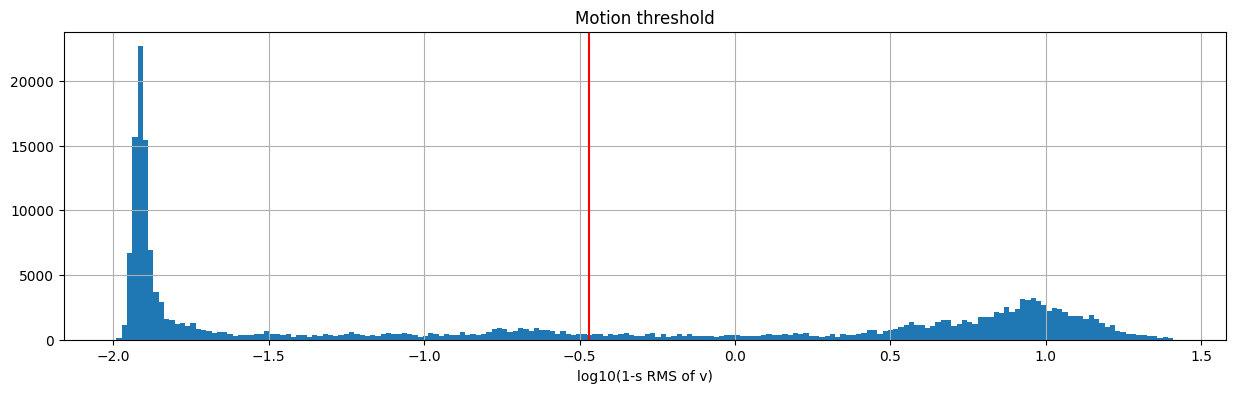

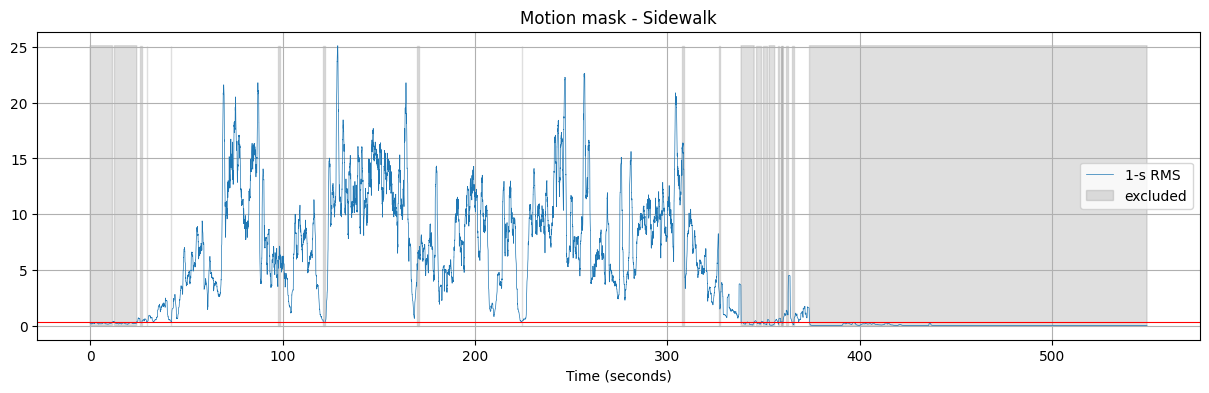

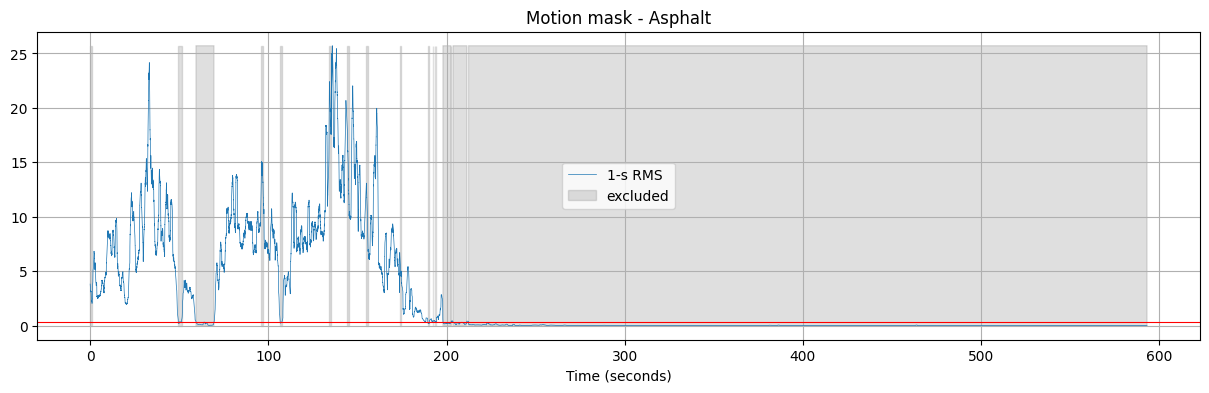

In [7]:
# 6. Motion mask: remove stationary intervals using a threshold on the 1-s RMS of v

def rolling_rms(x, n):
    return np.sqrt(pd.Series(x ** 2).rolling(n, center = True, min_periods = 1).mean().to_numpy())

# threshold that best splits the histogram into two groups
def otsu_threshold(values, bins = 256):
    hist, edges = np.histogram(values, bins = bins)
    mids = (edges[:-1] + edges[1:]) / 2
    w0 = np.cumsum(hist)
    w1 = w0[-1] - w0
    m0 = np.cumsum(hist * mids) / np.maximum(w0, 1)
    m1 = (np.sum(hist * mids) - np.cumsum(hist * mids)) / np.maximum(w1, 1)
    return mids[np.argmax(w0 * w1 * (m0 - m1) ** 2)]

# 1-s rolling RMS of v, per piece
n_win = int(motion_win * fs)
for name, p in proc.items():
    p["v_rms1s"] = p.groupby("segment")["v"].transform(lambda s: rolling_rms(s.to_numpy(), n_win))

# log scale: stationary and moving differ by orders of magnitude
log_rms = np.log10(np.concatenate([p.loc[~p["edge"], "v_rms1s"].to_numpy() for p in proc.values()]) + 1e-6)
if motion_thresh is None:
    motion_thresh = 10 ** otsu_threshold(log_rms)
print(f"motion threshold = {motion_thresh:.3f} m/s^2")

for name, p in proc.items():
    # moving = above threshold, not in the first second, not manually excluded
    moving = (p["v_rms1s"] > motion_thresh) & ~p["edge"]
    for t0, t1 in manual_exclude.get(name, []):
        moving = moving & ~p["t"].between(t0, t1)
    p["moving"] = moving
    print(f"{name}: moving {moving.mean() * 100:.1f}% ({moving.sum() / fs:.1f} s)")

plt.figure(figsize = (15, 4))
plt.hist(log_rms, bins = 200)
plt.axvline(np.log10(motion_thresh), color = "red")
plt.title("Motion threshold")
plt.xlabel("log10(1-s RMS of v)"); plt.grid(True); plt.show()

for name, p in proc.items():
    plt.figure(figsize = (15, 4))
    plt.plot(p["t"], p["v_rms1s"], linewidth = 0.5, label = "1-s RMS")
    plt.fill_between(p["t"], 0, p["v_rms1s"].max(), where = ~p["moving"], color = "gray", alpha = 0.25, label = "excluded")
    plt.axhline(motion_thresh, color = "red", linewidth = 0.8)
    plt.title(f"Motion mask - {name}")
    plt.xlabel("Time (seconds)"); plt.legend(); plt.grid(True)
    plt.savefig(out_dir / f"motion_mask_{name}.png", dpi = 200, bbox_inches = "tight")
    plt.show()

In [8]:
# 7. PSD (Welch, P_y + P_z) on moving stretches and spectral features (Phase 2.5)

# start/end indices of contiguous True runs
def moving_stretches(mask):
    m = np.concatenate([[False], np.asarray(mask, bool), [False]])
    d = np.diff(m.astype(int))
    return list(zip(np.where(d == 1)[0], np.where(d == -1)[0]))

# Welch PSD over moving stretches, P_y + P_z, length-weighted average
def psd_moving(p, col_suffix = "_bp", axes = ("ay", "az")):
    total, weight, f = None, 0, None
    for seg_id, s in p.groupby("segment"):
        for a, b in moving_stretches(s["moving"].to_numpy()):
            if b - a < nperseg:
                continue
            P_sum = 0
            for axis in axes:
                col = axis + col_suffix if col_suffix else axis
                f, P = welch(s[col].to_numpy()[a:b], fs = fs, nperseg = nperseg)
                P_sum = P_sum + P
            w = (b - a) // (nperseg // 2)
            total = P_sum * w if total is None else total + P_sum * w
            weight += w
    return f, total / weight

# f_peak, spectral centroid, band RMS
def spectral_features(f, P):
    sel = (f >= band[0]) & (f <= band[1])
    feats = {"f_peak": f[sel][np.argmax(P[sel])],
             "f_c": np.sum(f[sel] * P[sel]) / np.sum(P[sel])}
    for b_name, (lo, hi) in freq_bands.items():
        b = (f >= lo) & (f < hi)
        feats[f"band_{b_name}"] = np.sqrt(trapz(P[b], f[b]))
    return feats

psd = {}
for name, p in proc.items():
    psd[name] = psd_moving(p)

In [9]:
# 8. Event detection (Phase 2.5): sharp hits; thresholds are provisional until tuned on Segment C

# provisional thresholds from the moving samples of all runs
v_moving = np.concatenate([p.loc[p["moving"], "v"].to_numpy() for p in proc.values()])
if event_theta is None:
    event_theta = np.median(v_moving) + 6 * stats.median_abs_deviation(v_moving, scale = "normal")
if event_sigma is None:
    event_sigma = event_theta / 4
print(f"event theta = {event_theta:.2f} m/s^2, sigma = {event_sigma:.2f} m/s^2")

# v above theta AND a sharp jump; merge hits closer than event_refractory
def detect_events(p):
    v = p["v"].to_numpy()
    dv = np.diff(v, prepend = v[0])
    candidates = np.where((v > event_theta) & (dv > event_sigma) & p["moving"].to_numpy())[0]
    t = p["t"].to_numpy()
    events, last_t = [], -np.inf
    for i in candidates:
        if t[i] - last_t >= event_refractory:
            events.append(i)
            last_t = t[i]
    return np.array(events, dtype = int)

events = {}
for name, p in proc.items():
    events[name] = detect_events(p)
    print(f"{name}: {len(events[name])} events")

event theta = 29.69 m/s^2, sigma = 7.42 m/s^2
Sidewalk: 229 events
Asphalt: 64 events


In [10]:
# 9. Phase 2 output table, one row per recording

# one row of the Phase 2 output table
def summarize(name, p, df_raw):
    moving = p["moving"].to_numpy()
    moving_s = moving.sum() / fs
    row = {"Run_id": name, "Surface": surface.get(name, name), "moving_s": round(moving_s, 1),
           "a_RMS": np.sqrt(np.mean(p.loc[moving, "v"] ** 2)),
           **spectral_features(*psd[name]),
           "events": len(events[name]), "events_per_s": len(events[name]) / moving_s}
    # distance-based event rate when speed is recorded
    if "speed_mps" in df_raw.columns:
        speed = np.interp(p["t"], df_raw["time_sec"], df_raw["speed_mps"])
        distance = np.sum(speed[moving]) / fs
        row["distance_m"] = distance
        row["events_per_100m"] = len(events[name]) / distance * 100 if distance > 0 else np.nan
    return row

phase2 = pd.DataFrame([summarize(name, proc[name], datasets[name]) for name in proc])

# consistency check: should be close to a_RMS
phase2["check_sqrt_sum_bands"] = np.sqrt(sum(phase2[f"band_{b}"] ** 2 for b in freq_bands))
phase2.to_csv(out_dir / "phase2_output.csv", index = False)
phase2.round(3)

,Run_id,Surface,moving_s,a_RMS,f_peak,f_c,band_low,band_mid,band_high,events,events_per_s,check_sqrt_sum_bands
0,Sidewalk,Sidewalk,325.7,8.911,30.5,30.428,1.386,4.284,7.907,229,0.703,9.099
1,Asphalt,Asphalt,177.2,8.892,31.5,33.203,1.243,4.254,8.047,64,0.361,9.187


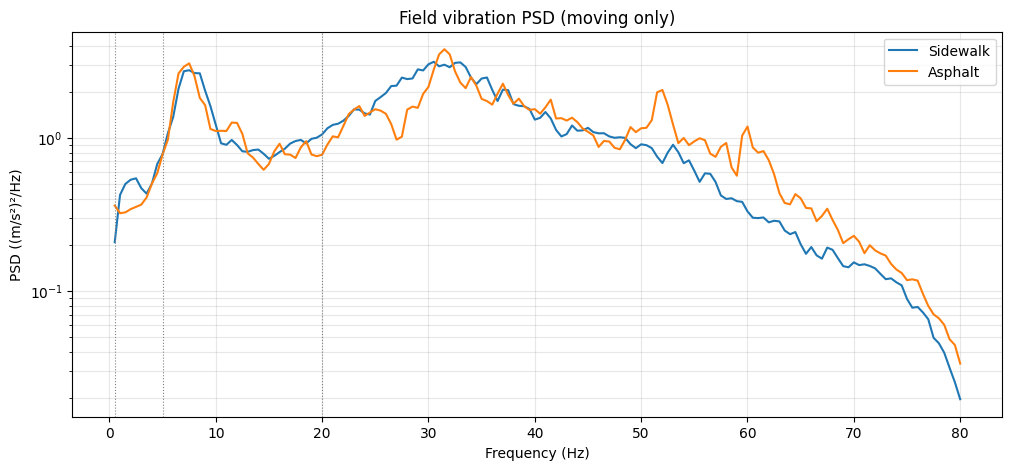

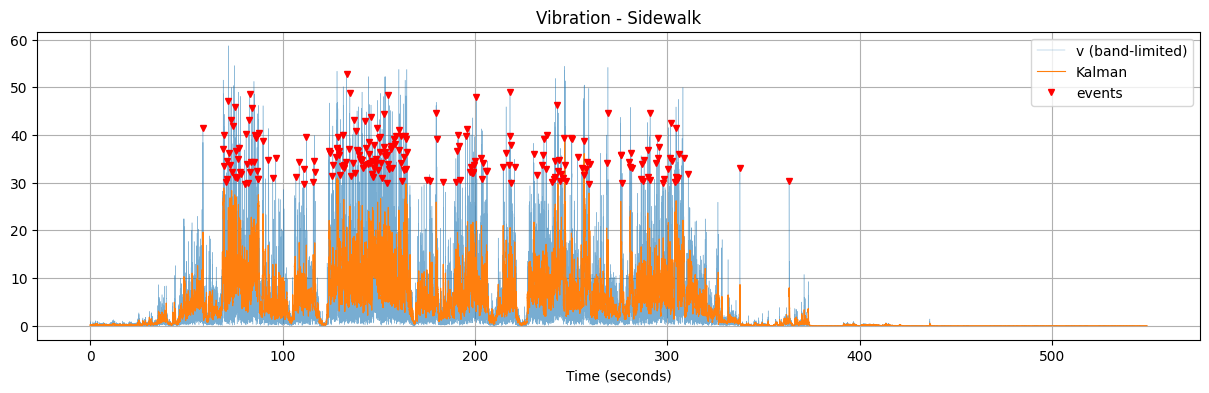

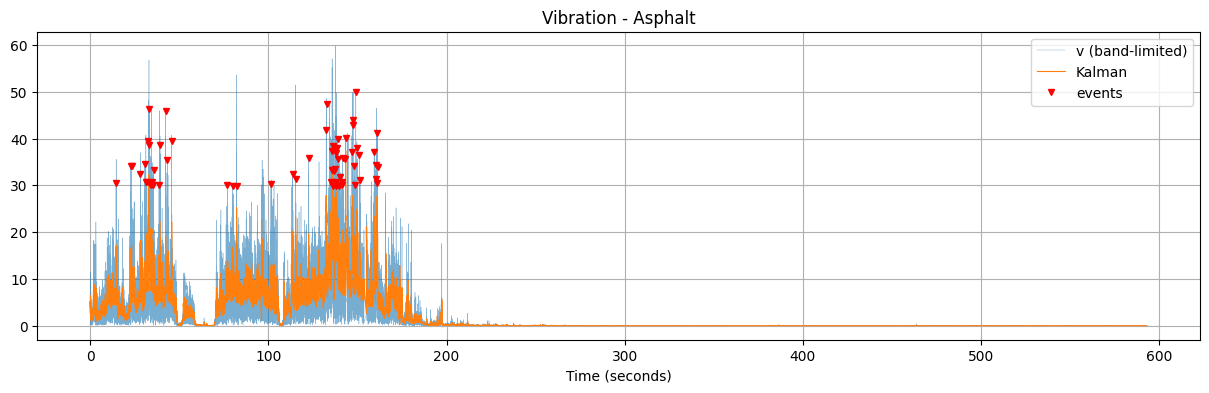

In [11]:
# 10. Figures: PSD of both surfaces and vibration time series with events

# PSD of all recordings
plt.figure(figsize = (12, 5))
for name, (f, P) in psd.items():
    sel = (f >= band[0]) & (f <= band[1])
    plt.semilogy(f[sel], P[sel], label = name)
for lo, hi in freq_bands.values():
    plt.axvline(lo, color = "gray", linestyle = ":", linewidth = 0.8)
plt.title("Field vibration PSD (moving only)")
plt.xlabel("Frequency (Hz)"); plt.ylabel("PSD ((m/s²)²/Hz)"); plt.legend(); plt.grid(True, which = "both", alpha = 0.3)
plt.savefig(out_dir / "field_psd.png", dpi = 300, bbox_inches = "tight")
plt.show()

# time series with Kalman envelope and events
for name, p in proc.items():
    plt.figure(figsize = (15, 4))
    plt.plot(p["t"], p["v"], linewidth = 0.3, alpha = 0.6, label = "v (band-limited)")
    plt.plot(p["t"], p["v_kalman"], linewidth = 0.8, label = "Kalman")
    ev = events[name]
    plt.plot(p["t"].to_numpy()[ev], p["v"].to_numpy()[ev], "rv", markersize = 4, label = "events")
    plt.title(f"Vibration - {name}")
    plt.xlabel("Time (seconds)"); plt.legend(); plt.grid(True)
    plt.savefig(out_dir / f"field_time_series_{name}.png", dpi = 200, bbox_inches = "tight")
    plt.show()

In [12]:
# 11. Surface separability in the field (Phase 4.5): Cohen's d, Welch t-test, Mann-Whitney U
#     on 2-s windows; adjacent windows are correlated, so p-values are optimistic

# a_RMS and band RMS for each mostly-moving window
def window_metrics(name, p):
    rows = []
    n = int(stat_win * fs)
    for seg_id, s in p.groupby("segment"):
        for a in range(0, len(s) - n + 1, n):
            w = s.iloc[a:a + n]
            if w["moving"].mean() < min_moving_frac:
                continue
            P_sum = 0
            for axis in ("ay", "az"):
                f, P = welch(w[f"{axis}_bp"].to_numpy(), fs = fs, nperseg = n // 2)
                P_sum = P_sum + P
            row = {"run": name, "surface": surface.get(name, name), "t0": w["t"].iloc[0],
                   "a_RMS": np.sqrt(np.mean(w["v"] ** 2))}
            for b_name, (lo, hi) in freq_bands.items():
                b = (f >= lo) & (f < hi)
                row[f"band_{b_name}"] = np.sqrt(trapz(P_sum[b], f[b]))
            rows.append(row)
    return rows

# effect size with pooled standard deviation
def cohens_d(x1, x2):
    x1, x2 = np.asarray(x1, float), np.asarray(x2, float)
    n1, n2 = len(x1), len(x2)
    s_pooled = np.sqrt(((n1 - 1) * x1.var(ddof = 1) + (n2 - 1) * x2.var(ddof = 1)) / (n1 + n2 - 2))
    return (x1.mean() - x2.mean()) / s_pooled

# Cohen's d, Welch t-test and Mann-Whitney U for each metric
def separability(df, group_col = "surface", metrics = ("a_RMS", "band_low", "band_mid", "band_high")):
    g1, g2 = df[group_col].unique()[:2]
    rows = []
    for m in metrics:
        x1 = df.loc[df[group_col] == g1, m]
        x2 = df.loc[df[group_col] == g2, m]
        t = stats.ttest_ind(x1, x2, equal_var = False)
        u = stats.mannwhitneyu(x1, x2)
        rows.append({"metric": m, f"mean_{g1}": x1.mean(), f"mean_{g2}": x2.mean(),
                     f"n_{g1}": len(x1), f"n_{g2}": len(x2),
                     "cohens_d": cohens_d(x1, x2), "welch_t": t.statistic, "p_t": t.pvalue,
                     "p_mannwhitney": u.pvalue})
    return pd.DataFrame(rows)

windows = pd.DataFrame([row for name, p in proc.items() for row in window_metrics(name, p)])
windows.to_csv(out_dir / "field_window_metrics.csv", index = False)
print(f"{len(windows)} windows of {stat_win} s")

sep_field = separability(windows)
sep_field.to_csv(out_dir / "field_separability.csv", index = False)
sep_field.round(4)

226 windows of 2.0 s


,metric,mean_Sidewalk,mean_Asphalt,n_Sidewalk,n_Asphalt,cohens_d,welch_t,p_t,p_mannwhitney
0,a_RMS,8.0461,7.7810,149,77,0.0593,0.4296,0.6680,0.5797
1,band_low,1.0562,0.8684,149,77,0.3127,2.3641,0.0191,0.0210
2,band_mid,3.7257,3.5959,149,77,0.0585,0.4252,0.6713,0.5336
3,band_high,6.7933,6.6271,149,77,0.0393,0.2863,0.7750,0.7589


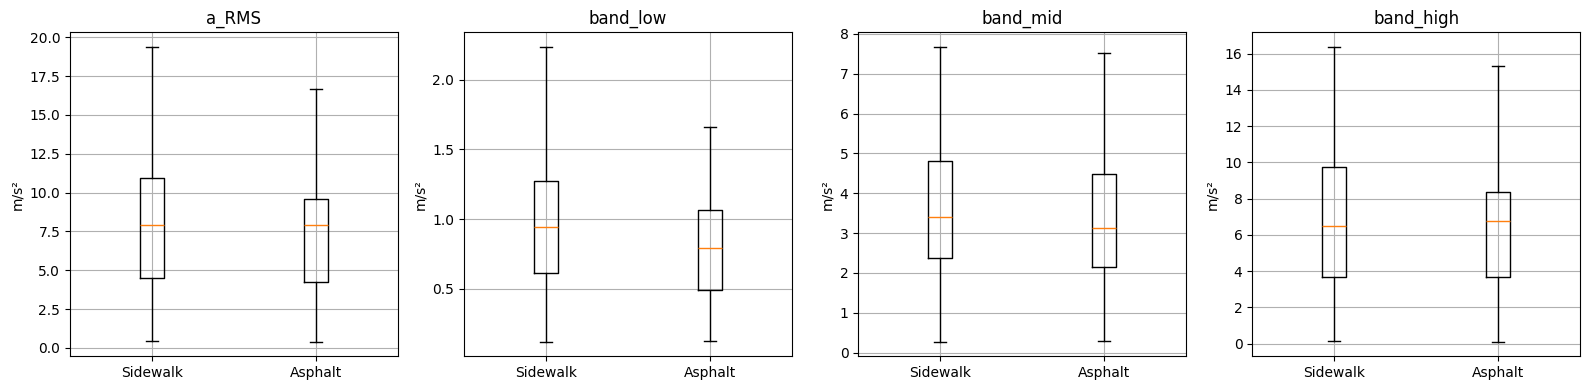

In [13]:
# 12. Figure: separability box plots

# one box plot per metric
fig, axes = plt.subplots(1, 4, figsize = (16, 4))
groups = list(windows["surface"].unique())
for ax_plot, m in zip(axes, ["a_RMS", "band_low", "band_mid", "band_high"]):
    ax_plot.boxplot([windows.loc[windows["surface"] == g, m] for g in groups], showfliers = False)
    ax_plot.set_xticks(range(1, len(groups) + 1))
    ax_plot.set_xticklabels(groups)
    ax_plot.set_title(m)
    ax_plot.set_ylabel("m/s²")
    ax_plot.grid(True)
plt.tight_layout()
plt.savefig(out_dir / "field_separability.png", dpi = 300, bbox_inches = "tight")
plt.show()

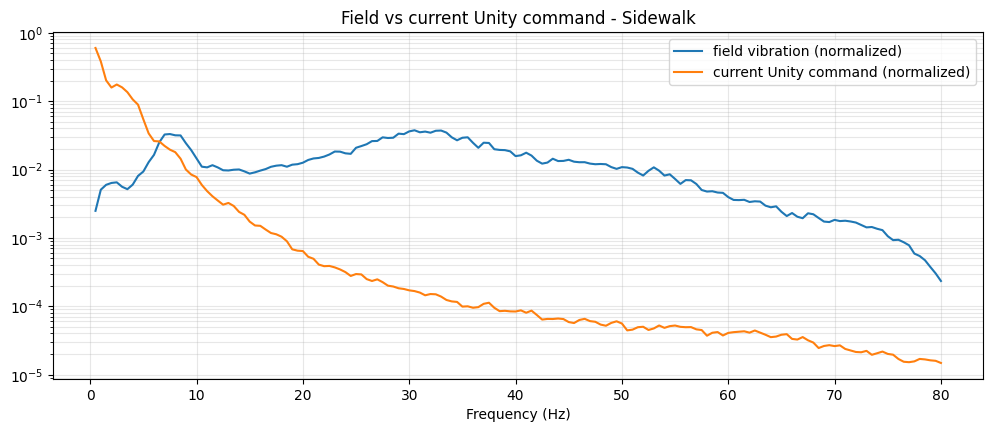

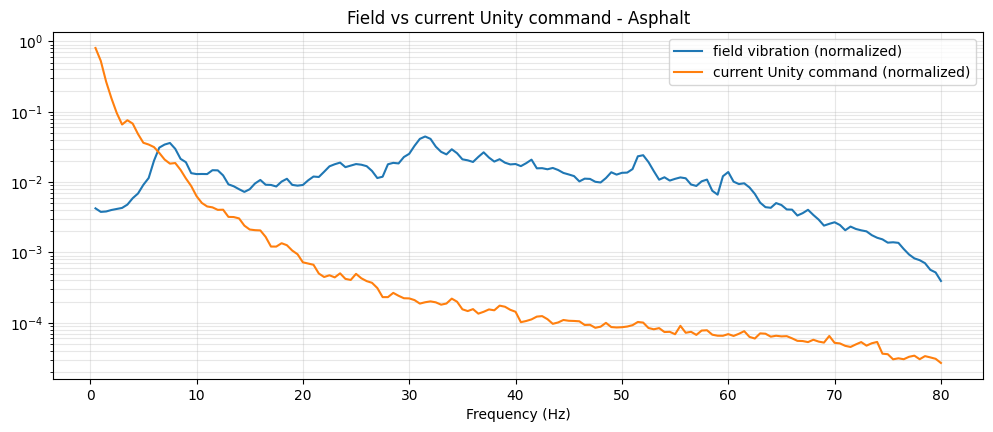

,Run_id,field_frac_low,field_frac_mid,field_frac_high,command_frac_low,command_frac_mid,command_frac_high
0,Sidewalk,0.0232,0.2216,0.7552,0.8609,0.1329,0.0062
1,Asphalt,0.0183,0.2145,0.7672,0.8596,0.1315,0.0089


In [14]:
# 13. Share of power per band: real vibration vs. the command currently sent to Unity

# rebuild the command currently sent to Unity
def paper_c_command(datasets):
    smooth = {}
    for name, df in datasets.items():
        dt = df["time_sec"].diff().median()
        rc = 1.0 / (2 * np.pi * paper_lpf_fc)
        alpha = rc / (rc + dt)
        dyn = {}
        for axis in ("ay", "az"):
            x = df[axis].to_numpy(float)
            dyn[axis] = x - lfilter([1 - alpha], [1, -alpha], x, zi = [alpha * x[0]])[0]
        smooth[name] = kalman_smooth(np.sqrt(dyn["ay"] ** 2 + dyn["az"] ** 2))
    # global min-max normalization over all recordings
    all_values = np.concatenate(list(smooth.values()))
    global_min, global_max = all_values.min(), all_values.max()
    command = {}
    for name, m in smooth.items():
        u = (m - global_min) / (global_max - global_min)
        # smoothstep threshold
        x = np.clip((u - threshold_low) / (threshold_high - threshold_low), 0, 1)
        command[name] = u * x * x * (3 - 2 * x)
    return command

# share of 0.5-80 Hz power in each band
def band_fractions(f, P):
    energy = {}
    for b_name, (lo, hi) in freq_bands.items():
        b = (f >= lo) & (f < hi)
        energy[b_name] = trapz(P[b], f[b])
    total = sum(energy.values())
    return {b_name: e / total for b_name, e in energy.items()}

command = paper_c_command(datasets)

rows = []
for name, p in proc.items():
    # put the command on the same uniform grid as the field data
    p["command"] = np.interp(p["t"], datasets[name]["time_sec"], command[name])
    f_field, P_field = psd[name]
    f_cmd, P_cmd = psd_moving(p, col_suffix = "", axes = ("command",))
    frac_field = band_fractions(f_field, P_field)
    frac_cmd = band_fractions(f_cmd, P_cmd)
    rows.append({"Run_id": name,
                 **{f"field_frac_{b}": frac_field[b] for b in freq_bands},
                 **{f"command_frac_{b}": frac_cmd[b] for b in freq_bands}})

    sel = (f_field >= band[0]) & (f_field <= band[1])
    # both spectra normalized to unit area
    plt.figure(figsize = (12, 4.5))
    plt.semilogy(f_field[sel], P_field[sel] / trapz(P_field[sel], f_field[sel]), label = "field vibration (normalized)")
    plt.semilogy(f_cmd[sel], P_cmd[sel] / trapz(P_cmd[sel], f_cmd[sel]), label = "current Unity command (normalized)")
    plt.title(f"Field vs current Unity command - {name}")
    plt.xlabel("Frequency (Hz)"); plt.legend(); plt.grid(True, which = "both", alpha = 0.3)
    plt.savefig(out_dir / f"field_vs_command_psd_{name}.png", dpi = 300, bbox_inches = "tight")
    plt.show()

band_frac = pd.DataFrame(rows)
band_frac.to_csv(out_dir / "field_vs_command_band_fractions.csv", index = False)
band_frac.round(4)

steady-state Kalman gain K = 0.0951, equivalent low-pass ~3.18 Hz


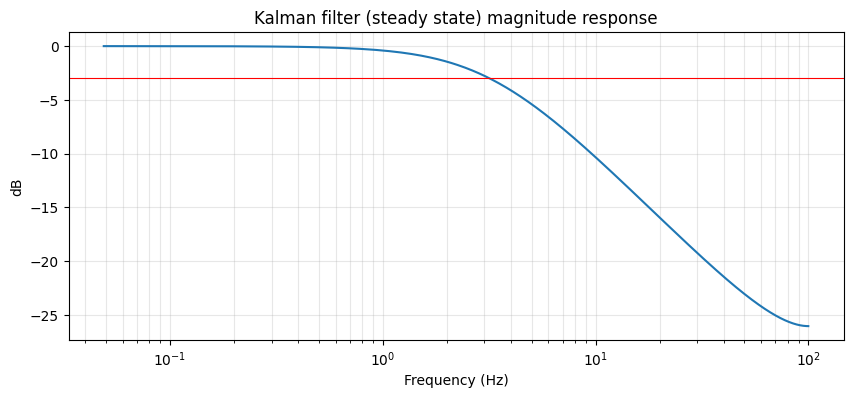

In [15]:
# 14. Kalman filter frequency response (steady state = first-order low-pass)

# steady-state Kalman gain and equivalent first-order cut-off
P_prior_ss = (q + np.sqrt(q ** 2 + 4 * q * r)) / 2
K_ss = P_prior_ss / (P_prior_ss + r)
f_cut = -np.log(1 - K_ss) * fs / (2 * np.pi)
print(f"steady-state Kalman gain K = {K_ss:.4f}, equivalent low-pass ~{f_cut:.2f} Hz")

# magnitude response of y[n] = (1-K) y[n-1] + K x[n]
w, h = freqz([K_ss], [1, -(1 - K_ss)], worN = 2048, fs = fs)
plt.figure(figsize = (10, 4))
plt.semilogx(w[1:], 20 * np.log10(np.abs(h[1:])))
plt.axhline(-3, color = "red", linewidth = 0.8)
plt.title("Kalman filter (steady state) magnitude response")
plt.xlabel("Frequency (Hz)"); plt.ylabel("dB"); plt.grid(True, which = "both", alpha = 0.3)
plt.savefig(out_dir / "kalman_response.png", dpi = 300, bbox_inches = "tight")
plt.show()